# Bank Management System — Data Analysis 

## Project Objective
Analyze the bank's customer, account, transaction, loan, card, branch, and support-call data to identify customer behavior, financial patterns, operational trends, and business opportunities.

## Analytical Workflow
**Source Data → Power Query Cleaning → Python EDA → Feature Engineering → RFM Analysis → Visualization → Power BI Dashboard**

This notebook documents the Python analysis performed after the initial data-cleaning stage in Power Query.

## 1. Dataset Before Cleaning

The original source files were loaded first so that data quality could be assessed before any transformation.

| Table | Original Rows | Columns |
|---|---:|---:|
| Customers | 510,000 | 8 |
| Accounts | 721,000 | 6 |
| Cards | 918,000 | 6 |
| Loans | 300,000 | 7 |
| Transactions | 6,000,000 | 6 |
| Support Calls | 400,000 | 6 |
| Calendar | 3,650 | 7 |
| Branches | 312 | 5 |

## 2. Data Cleaning in Power Query

Initial data preparation was completed in **Power Query** before the Python analysis.

### Main cleaning activities
- Removed duplicate records.
- Handled missing values using appropriate replacement rules.
- Standardized inconsistent text values and naming.
- Corrected data types.
- Split the combined transaction date/time field where required.
- Prepared the cleaned tables for Python analysis and later Power BI modeling.

**Power Query handles source-data cleaning, while Python focuses on EDA, feature engineering, RFM analysis, and analytical insights.**

## 3. Dataset After Power Query Cleaning

After the Power Query cleaning stage, the cleaned files were exported and loaded into Python.

| Table | Rows After Cleaning | Columns |
|---|---:|---:|
| Customers | 500,000 | 8 |
| Accounts | 700,000 | 6 |
| Cards | 900,000 | 6 |
| Loans | 300,000 | 7 |
| Transactions | 6,000,000 | 6 |
| Support Calls | 400,000 | 6 |
| Calendar | 3,650 | 7 |
| Branches | 300 | 5 |

The reduction in row counts mainly reflects duplicate removal during the cleaning stage.

## 4. Import Required Libraries

The libraries below support data loading, manipulation, analysis, and visualization:

- **pandas** — data loading and tabular analysis
- **NumPy** — numerical operations
- **Matplotlib** — visualization
- **Seaborn** — statistical visualization
- **Plotly** — interactive visualization
- **os** — file and folder handling

In [143]:
import pandas as pd
import os

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Part A — Exploratory Data Analysis Before Cleaning

This section examines the original source data before cleaning.

### Objectives
- Confirm dataset dimensions.
- Identify missing values.
- Identify duplicate records.
- Establish a baseline for data quality.

### A1. Load the Original Source Data

Load the original CSV files so their structure and data-quality issues can be assessed before cleaning.

In [144]:
folder_path = r"C:\Users\fagr\Desktop\bank management system"

Customers = pd.read_csv(os.path.join(folder_path, "Customers.csv"))
Accounts = pd.read_csv(os.path.join(folder_path, "Accounts.csv"))
Cards = pd.read_csv(os.path.join(folder_path, "Cards.csv"))
Loans = pd.read_csv(os.path.join(folder_path, "Loans.csv"))
Transactions = pd.read_csv(os.path.join(folder_path, "Transactions.csv"))
SupportCalls = pd.read_csv(os.path.join(folder_path, "SupportCalls.csv"))
Calendar = pd.read_csv(os.path.join(folder_path, "Calendar.csv"))
Branches = pd.read_csv(os.path.join(folder_path, "Branches.csv"))

### A2. Initial Data Quality Check

For each table, check missing values and duplicated rows.

These checks provide a baseline for evaluating the effectiveness of the Power Query cleaning stage.

In [145]:
before_cleaning = {
    "Customers": Customers,
    "Accounts": Accounts,
    "Cards": Cards,
    "Loans": Loans,
    "Transactions": Transactions,
    "SupportCalls": SupportCalls,
    "Calendar": Calendar,
    "Branches": Branches
}

for name, df in before_cleaning.items():
    print(f"{name}: {df.shape}")

Customers: (510000, 8)
Accounts: (721000, 6)
Cards: (918000, 6)
Loans: (300000, 7)
Transactions: (6000000, 6)
SupportCalls: (400000, 6)
Calendar: (3650, 7)
Branches: (312, 5)


In [146]:
for name, df in before_cleaning.items():
    print(f"{name}: {df.isnull().sum().sum()}")

Customers: 71437
Accounts: 43632
Cards: 45396
Loans: 0
Transactions: 0
SupportCalls: 0
Calendar: 0
Branches: 23


In [147]:
for name, df in before_cleaning.items():
    print(f"{name}: {df.duplicated().sum()}")

Customers: 10000
Accounts: 21000
Cards: 18000
Loans: 0
Transactions: 0
SupportCalls: 0
Calendar: 0
Branches: 12


# Part B — Exploratory Data Analysis After Cleaning

The cleaned files produced by Power Query are now loaded into Python.

### Objectives
1. Confirm that the cleaned data was loaded correctly.
2. Recheck data quality.
3. Convert date fields to appropriate datetime types for analysis.

### B1. Load the Cleaned Data

Load the cleaned CSV files exported from Power Query.

These cleaned tables are the main inputs for the remaining Python analysis.

In [148]:
transactions = pd.read_csv("Transactions (Clean).csv")
support_calls = pd.read_csv("SupportCalls (Clean).csv")
loans = pd.read_csv("Loans (Clean).csv")
customers = pd.read_csv("Customers (Clean).csv")
cards = pd.read_csv("Cards (Clean).csv")
calendar = pd.read_csv("Calendar (Clean).csv")
branches = pd.read_csv("Branches (Clean).csv")
accounts = pd.read_csv("Accounts (Clean).csv")

### B2. Data Quality Validation and Date Preparation

Run a consistent EDA summary for every cleaned table.

The checks include:
- Data types
- Total missing values
- Duplicate rows
- Basic numerical statistics

Date columns are converted to **datetime** so time-based analysis and feature engineering can be performed reliably.

In [149]:
clean_data = {
    "Customers": customers,
    "Accounts": accounts,
    "Cards": cards,
    "Loans": loans,
    "Transactions": transactions,
    "SupportCalls": support_calls,
    "Calendar": calendar,
    "Branches": branches
}

for name, df in clean_data.items():
    print(f"{name}: {df.shape}")

Customers: (500000, 8)
Accounts: (700000, 6)
Cards: (900000, 6)
Loans: (300000, 7)
Transactions: (6000000, 6)
SupportCalls: (400000, 6)
Calendar: (3650, 7)
Branches: (300, 5)


In [150]:
def eda_summary(df):
    df.info()
    print("\nTotal Null Values:", df.isnull().sum().sum())
    print("Duplicated Rows:", df.duplicated().sum())
    display(df.head())

In [151]:
eda_summary(customers)

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Customer_ID       500000 non-null  str  
 1   Customer_Name     500000 non-null  str  
 2   Gender            500000 non-null  str  
 3   Age               500000 non-null  int64
 4   State             500000 non-null  str  
 5   Customer_Segment  500000 non-null  str  
 6   Join_Date         500000 non-null  str  
 7   Branch_ID         500000 non-null  str  
dtypes: int64(1), str(7)
memory usage: 30.5 MB

Total Null Values: 0
Duplicated Rows: 0


,Customer_ID,Customer_Name,Gender,Age,State,Customer_Segment,Join_Date,Branch_ID
0,CUST1008484,Ahmed El-Sayed,Male,40,Aswan,Affluent,31-12-21,BR1002
1,CUST1113023,Tarek Kamel,Male,40,Aswan,Affluent,27-12-22,BR1220
2,CUST1052554,Mahmoud Kamel,Male,40,Aswan,Affluent,23-08-21,BR1016
3,CUST1009942,Ahmed Fawzy,Male,40,Aswan,Affluent,19-01-16,BR1277
4,CUST1005361,Mohamed Fawzy,Male,40,Aswan,Affluent,01-01-20,BR1095


### B3. Accounts — Data Validation and Date Conversion

Review the cleaned **Accounts** table and convert `Created_Date` to datetime.

A valid datetime field is required for account age and other time-based features.

In [152]:
eda_summary(accounts)

<class 'pandas.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Account_ID    700000 non-null  str    
 1   Customer_ID   700000 non-null  str    
 2   Account_Type  700000 non-null  str    
 3   Balance       700000 non-null  float64
 4   Status        700000 non-null  str    
 5   Created_Date  700000 non-null  str    
dtypes: float64(1), str(5)
memory usage: 32.0 MB

Total Null Values: 0
Duplicated Rows: 0


,Account_ID,Customer_ID,Account_Type,Balance,Status,Created_Date
0,ACC10102810,CUST1105363,Certificate of Deposit,15177.02,Active,22-08-17
1,ACC10509313,CUST1117306,Certificate of Deposit,15177.02,Active,30-07-23
2,ACC10511959,CUST1387455,Certificate of Deposit,15177.02,Active,23-01-17
3,ACC10367254,CUST1287574,Certificate of Deposit,15177.02,Active,31-05-21
4,ACC10105630,CUST1460861,Certificate of Deposit,15177.02,Active,3/1/2022


In [153]:
accounts["Created_Date"] = pd.to_datetime(
    accounts["Created_Date"],
    format="mixed",
    dayfirst=True  
)

### B3. Transactions — Data Validation and Date Conversion

Review the cleaned **Transactions** table and convert `Transaction_Date` to datetime.

A valid datetime field is required for transaction trends, time-of-day analysis, and transaction features.

In [154]:
eda_summary(transactions)

<class 'pandas.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Transaction_ID    str    
 1   Account_ID        str    
 2   Branch_ID         str    
 3   Transaction_Type  str    
 4   Amount            float64
 5   Transaction_Date  str    
dtypes: float64(1), str(5)
memory usage: 274.7 MB

Total Null Values: 0
Duplicated Rows: 0


,Transaction_ID,Account_ID,Branch_ID,Transaction_Type,Amount,Transaction_Date
0,TX100000000,ACC10477204,BR1113,Deposit,2774.32,2019-01-30 00:45:47
1,TX100000001,ACC10060870,BR1142,Deposit,83.83,2024-06-08 01:43:19
2,TX100000002,ACC10541449,BR1114,Transfer,356.36,2019-03-08 20:01:20
3,TX100000003,ACC10630308,BR1132,Transfer,970.01,2023-11-07 02:44:14
4,TX100000004,ACC10568883,BR1051,POS Payment,203.82,2016-03-27 00:44:38


In [155]:
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Date"]
)

In [156]:

transactions['Transaction_Type'] = transactions['Transaction_Type'].str.replace('POS Payment', 'Point_Of_Sales_Payment')

In [157]:
transactions.head()

,Transaction_ID,Account_ID,Branch_ID,Transaction_Type,Amount,Transaction_Date
0,TX100000000,ACC10477204,BR1113,Deposit,2774.32,2019-01-30 00:45:47
1,TX100000001,ACC10060870,BR1142,Deposit,83.83,2024-06-08 01:43:19
2,TX100000002,ACC10541449,BR1114,Transfer,356.36,2019-03-08 20:01:20
3,TX100000003,ACC10630308,BR1132,Transfer,970.01,2023-11-07 02:44:14
4,TX100000004,ACC10568883,BR1051,Point_Of_Sales_Payment,203.82,2016-03-27 00:44:38


### B3. Support Calls — Data Validation and Date Conversion

Review the cleaned **Support Calls** table and convert `Call_Date` to datetime.

A valid datetime field is required for support activity over time.

In [158]:
eda_summary(support_calls)

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Call_ID               400000 non-null  str  
 1   Customer_ID           400000 non-null  str  
 2   Call_Type             400000 non-null  str  
 3   Resolution_Time_Mins  400000 non-null  int64
 4   Satisfaction_Score    400000 non-null  int64
 5   Call_Date             400000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 18.3 MB

Total Null Values: 0
Duplicated Rows: 0


,Call_ID,Customer_ID,Call_Type,Resolution_Time_Mins,Satisfaction_Score,Call_Date
0,CALL1000107,CUST1432927,Card Issues,1,4,30-07-21
1,CALL1000110,CUST1326164,Card Issues,1,4,09-05-22
2,CALL1000131,CUST1477525,Card Issues,1,4,21-01-19
3,CALL1000152,CUST1216083,Card Issues,1,4,05-08-20
4,CALL1000234,CUST1435972,Card Issues,1,4,19-07-24


In [159]:
support_calls["Call_Date"] = pd.to_datetime(
    support_calls["Call_Date"],
    format="%d-%m-%y"
)

### B3. Loans — Data Validation and Date Conversion

Review the cleaned **Loans** table and convert `Start_Date` to datetime.

A valid datetime field is required for loan-age and time-based analysis.

In [160]:
eda_summary(loans)

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Loan_ID        300000 non-null  str    
 1   Customer_ID    300000 non-null  str    
 2   Loan_Type      300000 non-null  str    
 3   Loan_Amount    300000 non-null  int64  
 4   Interest_Rate  300000 non-null  float64
 5   Loan_Status    300000 non-null  str    
 6   Start_Date     300000 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 16.0 MB

Total Null Values: 0
Duplicated Rows: 0


,Loan_ID,Customer_ID,Loan_Type,Loan_Amount,Interest_Rate,Loan_Status,Start_Date
0,LN1001150,CUST1333545,Personal Loan,58000,20.36,Active,02-08-16
1,LN1001165,CUST1418724,Personal Loan,58000,15.69,Active,13-02-24
2,LN1001435,CUST1045037,Personal Loan,58000,16.77,Active,11-02-15
3,LN1001675,CUST1117280,Personal Loan,58000,15.91,Active,22-06-22
4,LN1002907,CUST1109535,Personal Loan,58000,16.67,Active,19-04-16


In [161]:
loans["Start_Date"] = pd.to_datetime(
    loans["Start_Date"],
    format="%d-%m-%y"
)

### B3. Customers — Data Validation and Date Conversion

Review the cleaned **Customers** table and convert `Join_Date` to datetime.

A valid datetime field is required for customer tenure and joining cohorts.

In [162]:
eda_summary(customers)

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Customer_ID       500000 non-null  str  
 1   Customer_Name     500000 non-null  str  
 2   Gender            500000 non-null  str  
 3   Age               500000 non-null  int64
 4   State             500000 non-null  str  
 5   Customer_Segment  500000 non-null  str  
 6   Join_Date         500000 non-null  str  
 7   Branch_ID         500000 non-null  str  
dtypes: int64(1), str(7)
memory usage: 30.5 MB

Total Null Values: 0
Duplicated Rows: 0


,Customer_ID,Customer_Name,Gender,Age,State,Customer_Segment,Join_Date,Branch_ID
0,CUST1008484,Ahmed El-Sayed,Male,40,Aswan,Affluent,31-12-21,BR1002
1,CUST1113023,Tarek Kamel,Male,40,Aswan,Affluent,27-12-22,BR1220
2,CUST1052554,Mahmoud Kamel,Male,40,Aswan,Affluent,23-08-21,BR1016
3,CUST1009942,Ahmed Fawzy,Male,40,Aswan,Affluent,19-01-16,BR1277
4,CUST1005361,Mohamed Fawzy,Male,40,Aswan,Affluent,01-01-20,BR1095


In [163]:
customers["Join_Date"] = pd.to_datetime(
    customers["Join_Date"],
    format="%d-%m-%y"
)

### B3. Cards — Data Validation and Date Conversion

Review the cleaned **Cards** table and convert `Issue_Date` to datetime.

A valid datetime field is required for card-age analysis.

In [164]:
eda_summary(cards)

<class 'pandas.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Card_ID      900000 non-null  str  
 1   Customer_ID  900000 non-null  str  
 2   Account_ID   900000 non-null  str  
 3   Card_Type    900000 non-null  str  
 4   Card_Status  900000 non-null  str  
 5   Issue_Date   900000 non-null  str  
dtypes: str(6)
memory usage: 41.2 MB

Total Null Values: 0
Duplicated Rows: 0


,Card_ID,Customer_ID,Account_ID,Card_Type,Card_Status,Issue_Date
0,CARD10880932,CUST1013164,ACC10188248,Debit,Active,16-07-24
1,CARD10286407,CUST1438318,ACC10200272,Debit,Active,05-03-16
2,CARD10256654,CUST1307242,ACC10604448,Debit,Active,18-03-17
3,CARD10126694,CUST1226308,ACC10552529,Debit,Active,28-12-18
4,CARD10051744,CUST1497723,ACC10003986,Debit,Active,12-02-18


In [165]:
cards["Issue_Date"] = pd.to_datetime(
    cards["Issue_Date"],
    format="%d-%m-%y"
)

### B9. Calendar — Data Validation

Review the Calendar table and confirm that the date dimension is available for time-based analysis and Power BI modeling.

In [166]:
eda_summary(calendar)

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Date          3650 non-null   str  
 1   Year          3650 non-null   int64
 2   Quarter       3650 non-null   str  
 3   Month_Number  3650 non-null   int64
 4   Month_Name    3650 non-null   str  
 5   Day_of_Week   3650 non-null   str  
 6   Is_Weekend    3650 non-null   str  
dtypes: int64(2), str(5)
memory usage: 199.7 KB

Total Null Values: 0
Duplicated Rows: 0


,Date,Year,Quarter,Month_Number,Month_Name,Day_of_Week,Is_Weekend
0,02-07-15,2015,Q3,7,July,Thursday,No
1,09-07-15,2015,Q3,7,July,Thursday,No
2,16-07-15,2015,Q3,7,July,Thursday,No
3,23-07-15,2015,Q3,7,July,Thursday,No
4,30-07-15,2015,Q3,7,July,Thursday,No


### B10. Branches — Data Validation

Review the cleaned Branches table and confirm that branch information is ready for branch-level analysis.

In [167]:
eda_summary(branches)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Branch_ID     300 non-null    str  
 1   Branch_Name   300 non-null    str  
 2   State         300 non-null    str  
 3   Manager_Name  300 non-null    str  
 4   Opening_Year  300 non-null    int64
dtypes: int64(1), str(4)
memory usage: 11.8 KB

Total Null Values: 0
Duplicated Rows: 0


,Branch_ID,Branch_Name,State,Manager_Name,Opening_Year
0,BR1228,Branch 229 - Minya,Assiut,Manager 229,2018
1,BR1009,Branch 10 - Menofia,Beheira,Manager 10,2013
2,BR1057,Branch 58 - Faiyum,Aswan,Manager 58,2021
3,BR1060,Branch 61 - Faiyum,Red Sea,Manager 61,2005
4,BR1025,Branch 26 - Aswan,Alexandria,Manager 26,2011


# Part C — Feature Engineering

Feature engineering creates analytical variables from the cleaned data.

The objective is to transform raw fields into business-friendly indicators that can be used in Python analysis and Power BI dashboards.

### C1. Customers Features

Create analytical features for Customers: `Age_Group`, `Tenure_Years`, and `Join_Cohort`.

These features support customer segmentation and lifecycle analysis.

In [168]:
# Group customers into meaningful age ranges.
customers["Age_Group"] = pd.cut(
    customers["Age"],
    bins=[18,25,35,45,60,100],
    labels=["18-25","26-35","36-45","46-60","60+"],
    include_lowest=True
)

# Calculate customer tenure in years.
today = customers["Join_Date"].max()

customers["Tenure_Years"] = (
    (today - customers["Join_Date"]).dt.days/365
).round(1)

# Create a customer joining-period cohort.
customers["Join_Cohort"] = customers["Join_Date"].dt.to_period("M").astype(str)

In [169]:
customers.head()

,Customer_ID,Customer_Name,Gender,Age,State,Customer_Segment,Join_Date,Branch_ID,Age_Group,Tenure_Years,Join_Cohort
0,CUST1008484,Ahmed El-Sayed,Male,40,Aswan,Affluent,2021-12-31,BR1002,36-45,3.0,2021-12
1,CUST1113023,Tarek Kamel,Male,40,Aswan,Affluent,2022-12-27,BR1220,36-45,2.0,2022-12
2,CUST1052554,Mahmoud Kamel,Male,40,Aswan,Affluent,2021-08-23,BR1016,36-45,3.4,2021-08
3,CUST1009942,Ahmed Fawzy,Male,40,Aswan,Affluent,2016-01-19,BR1277,36-45,9.0,2016-01
4,CUST1005361,Mohamed Fawzy,Male,40,Aswan,Affluent,2020-01-01,BR1095,36-45,5.0,2020-01


### C2. Accounts Features

Create analytical features for Accounts: `Account_Age_Years`, `Balance_Tier`, and `Accounts_Per_Customer`.

These features support account maturity, balance segmentation, and product ownership analysis.

In [170]:
# Calculate account age in years.
today = accounts["Created_Date"].max()

accounts["Account_Age_Years"] = (
    (today - accounts["Created_Date"]).dt.days/365
).round(1)

# Classify accounts into balance tiers.
accounts["Balance_Tier"] = pd.qcut(
    accounts["Balance"],
    q=3,
    labels=["Low","Medium","High"]
)

# Calculate the number of accounts held by each customer.
accounts["Accounts_Per_Customer"] = (
    accounts.groupby("Customer_ID")["Account_ID"]
    .transform("count")
)

In [171]:
accounts.head()

,Account_ID,Customer_ID,Account_Type,Balance,Status,Created_Date,Account_Age_Years,Balance_Tier,Accounts_Per_Customer
0,ACC10102810,CUST1105363,Certificate of Deposit,15177.02,Active,2017-08-22,7.4,High,1
1,ACC10509313,CUST1117306,Certificate of Deposit,15177.02,Active,2023-07-30,1.4,High,2
2,ACC10511959,CUST1387455,Certificate of Deposit,15177.02,Active,2017-01-23,7.9,High,3
3,ACC10367254,CUST1287574,Certificate of Deposit,15177.02,Active,2021-05-31,3.6,High,5
4,ACC10105630,CUST1460861,Certificate of Deposit,15177.02,Active,2022-01-03,3.0,High,4


### C3. Cards Features

Create analytical features for Cards: `Card_Age`, `Cards_Per_Customer`, and `Active_Card_Flag`.

These features support card-product and customer-engagement analysis.

In [172]:
# Calculate card age in years.
today = cards["Issue_Date"].max()

cards["Card_Age"] = (
    (today-cards["Issue_Date"]).dt.days/365
).round(1)

# Calculate the number of cards held by each customer.
cards["Cards_Per_Customer"] = (
    cards.groupby("Customer_ID")["Card_ID"]
    .transform("count")
)

# Flag active cards for analysis.
cards["Active_Card_Flag"] = (
    cards["Card_Status"]
    .eq("Active")
    .astype(int)
)

In [173]:
cards.head()

,Card_ID,Customer_ID,Account_ID,Card_Type,Card_Status,Issue_Date,Card_Age,Cards_Per_Customer,Active_Card_Flag
0,CARD10880932,CUST1013164,ACC10188248,Debit,Active,2024-07-16,0.5,1,1
1,CARD10286407,CUST1438318,ACC10200272,Debit,Active,2016-03-05,8.8,1,1
2,CARD10256654,CUST1307242,ACC10604448,Debit,Active,2017-03-18,7.8,5,1
3,CARD10126694,CUST1226308,ACC10552529,Debit,Active,2018-12-28,6.0,3,1
4,CARD10051744,CUST1497723,ACC10003986,Debit,Active,2018-02-12,6.9,2,1


### C4. Loans Features

Create analytical features for Loans: `Loan_Age`, `Loan_Amount_Tier`, and `Has_Active_Loan`.

These features support loan portfolio and customer-loan analysis.

In [174]:
# Calculate loan age in years.
today = loans["Start_Date"].max()

loans["Loan_Age"] = (
    (today-loans["Start_Date"]).dt.days/365
).round(1)

# Classify loans into amount tiers.
loans["Loan_Amount_Tier"] = pd.qcut(
    loans["Loan_Amount"],
    q=3,
    labels=["Low","Medium","High"]
)

# Flag customers with an active loan.
loans["Has_Active_Loan"] = (
    loans["Loan_Status"]
    .eq("Active")
    .astype(int)
)

In [175]:
loans.head()

,Loan_ID,Customer_ID,Loan_Type,Loan_Amount,Interest_Rate,Loan_Status,Start_Date,Loan_Age,Loan_Amount_Tier,Has_Active_Loan
0,LN1001150,CUST1333545,Personal Loan,58000,20.36,Active,2016-08-02,8.4,Low,1
1,LN1001165,CUST1418724,Personal Loan,58000,15.69,Active,2024-02-13,0.9,Low,1
2,LN1001435,CUST1045037,Personal Loan,58000,16.77,Active,2015-02-11,9.9,Low,1
3,LN1001675,CUST1117280,Personal Loan,58000,15.91,Active,2022-06-22,2.5,Low,1
4,LN1002907,CUST1109535,Personal Loan,58000,16.67,Active,2016-04-19,8.7,Low,1


### C5. Transactions Features

Create analytical features for Transactions: transaction date/hour, `Is_Large_Transaction`, and `Net_Flow`.

These features support transaction timing, size, and cash-flow analysis.

In [176]:
# Extract transaction date and hour for time-based analysis.
transactions["Date"] = transactions["Transaction_Date"].dt.date
transactions["Hour"] = transactions["Transaction_Date"].dt.hour

# Flag transactions above the defined large-transaction threshold.
limit = transactions["Amount"].quantile(.95)

transactions["Is_Large_Transaction"] = (
    transactions["Amount"]>=limit
).astype(int)

# Calculate the net flow associated with each transaction.
transactions["Net_Flow"] = np.where(
    transactions["Transaction_Type"]=="Deposit",
    transactions["Amount"],
    -transactions["Amount"]
)

In [177]:
transactions.head()

,Transaction_ID,Account_ID,Branch_ID,Transaction_Type,Amount,Transaction_Date,Date,Hour,Is_Large_Transaction,Net_Flow
0,TX100000000,ACC10477204,BR1113,Deposit,2774.32,2019-01-30 00:45:47,2019-01-30,0,0,2774.32
1,TX100000001,ACC10060870,BR1142,Deposit,83.83,2024-06-08 01:43:19,2024-06-08,1,0,83.83
2,TX100000002,ACC10541449,BR1114,Transfer,356.36,2019-03-08 20:01:20,2019-03-08,20,0,-356.36
3,TX100000003,ACC10630308,BR1132,Transfer,970.01,2023-11-07 02:44:14,2023-11-07,2,0,-970.01
4,TX100000004,ACC10568883,BR1051,Point_Of_Sales_Payment,203.82,2016-03-27 00:44:38,2016-03-27,0,0,-203.82


### C6. Support Calls Features

Create analytical features for Support Calls: `Calls_Per_Customer`, `Avg_Satisfaction`, `Avg_Resolution_Time`, and `At_Risk_Flag`.

These features support support workload, service quality, and customer-risk analysis.

In [178]:
# Count support calls for each customer.
support_calls["Calls_Per_Customer"] = (
    support_calls.groupby("Customer_ID")["Call_ID"]
    .transform("count")
)

# Calculate each customer's average satisfaction score.
support_calls["Avg_Satisfaction"] = (
    support_calls.groupby("Customer_ID")["Satisfaction_Score"]
    .transform("mean")
)

# Calculate each customer's average resolution time.
support_calls["Avg_Resolution_Time"] = (
    support_calls.groupby("Customer_ID")["Resolution_Time_Mins"]
    .transform("mean")
)

# Flag customers meeting the defined support-risk criteria.
support_calls["At_Risk_Flag"] = np.where(
    (support_calls["Avg_Satisfaction"]<=2)
    &
    (support_calls["Calls_Per_Customer"]>=3),
    1,
    0
)

In [179]:
support_calls.head()

,Call_ID,Customer_ID,Call_Type,Resolution_Time_Mins,Satisfaction_Score,Call_Date,Calls_Per_Customer,Avg_Satisfaction,Avg_Resolution_Time,At_Risk_Flag
0,CALL1000107,CUST1432927,Card Issues,1,4,2021-07-30,1,4.0,1.0,0
1,CALL1000110,CUST1326164,Card Issues,1,4,2022-05-09,1,4.0,1.0,0
2,CALL1000131,CUST1477525,Card Issues,1,4,2019-01-21,1,4.0,1.0,0
3,CALL1000152,CUST1216083,Card Issues,1,4,2020-08-05,1,4.0,1.0,0
4,CALL1000234,CUST1435972,Card Issues,1,4,2024-07-19,2,4.5,13.5,0


### C7. Branches Features

Create analytical features for Branches: `Branch_Age`.

These features support branch maturity and branch-performance analysis.

In [180]:
# Calculate branch operating age in years.
current_year = pd.Timestamp.today().year

branches["Branch_Age"] = (
    current_year - branches["Opening_Year"]
)

In [181]:
branches.head()

,Branch_ID,Branch_Name,State,Manager_Name,Opening_Year,Branch_Age
0,BR1228,Branch 229 - Minya,Assiut,Manager 229,2018,8
1,BR1009,Branch 10 - Menofia,Beheira,Manager 10,2013,13
2,BR1057,Branch 58 - Faiyum,Aswan,Manager 58,2021,5
3,BR1060,Branch 61 - Faiyum,Red Sea,Manager 61,2005,21
4,BR1025,Branch 26 - Aswan,Alexandria,Manager 26,2011,15


# Part D — RFM Customer Analysis

RFM analysis evaluates customer engagement using three dimensions:

- **Recency (R)** — how recently the customer made a transaction.
- **Frequency (F)** — how often the customer transacted.
- **Monetary (M)** — how much the customer transacted.

The three dimensions are converted into scores and combined to create a customer-level engagement and value profile.

In [182]:
# Link transactions to customers through Account_ID.
transactions_rfm = transactions.merge(
    accounts[["Account_ID", "Customer_ID"]],
    on="Account_ID",
    how="left"
)

# Use the latest transaction date as the reference date for recency.
snapshot_date = transactions_rfm["Transaction_Date"].max()

# Aggregate transaction behavior at customer level to create the RFM table.
rfm = (
    transactions_rfm
    .groupby("Customer_ID")
    .agg(
        Recency=("Transaction_Date",
                 lambda x: (snapshot_date - x.max()).days),

        Frequency=("Transaction_ID", "count"),

        Monetary=("Amount", "sum")
    )
    .reset_index()
)

In [183]:
# Convert Recency, Frequency, and Monetary values into quintile-based scores and combine them into an RFM score.
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [184]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,CUST1000000,508,17,7072.95,1,4,2,142
1,CUST1000003,1265,6,1376.70,1,1,1,111
2,CUST1000004,310,7,3133.81,2,1,1,211
3,CUST1000005,766,6,2326.61,1,1,1,111
4,CUST1000006,77,26,23787.90,4,5,5,455


# Part E — Prepare Analytical Data for Power BI

Save the cleaned and feature-engineered tables as CSV files.

These final analytical files will be used as the data source for the Power BI dashboard.

In [185]:
os.makedirs("PowerBI_Data(2)", exist_ok=True)


In [186]:
files_to_save = {
    "Customers_Featured.csv": customers,
    "Accounts_Featured.csv": accounts,
    "Cards_Featured.csv": cards,
    "Loans_Featured.csv": loans,
    "Transactions_Featured.csv": transactions,
    "SupportCalls_Featured.csv": support_calls,
    "Branches_Featured.csv": branches,
    "Calendar_Featured.csv": calendar,
    "RFM.csv": rfm
}

for filename, df in files_to_save.items():
    df.to_csv(f"PowerBI_Data(2)/{filename}", index=False)

print("All files saved successfully.")

All files saved successfully.


In [187]:
print("✅ All files saved successfully to PowerBI_Data")

✅ All files saved successfully to PowerBI_Data


# Part F — Exploratory Visualizations and Business Questions

The visualizations below translate the analysis into business questions.

Each section follows:
**Business Question → Visualization → Key Takeaway**

The analysis covers customer behavior, accounts, transactions, loans, cards, support performance, branches, and RFM engagement.

In [ ]:
# Visualization helper functions used throughout the EDA section.
# Keep chart formatting consistent across the notebook.
# Visualization helper functions used throughout the EDA section.
import itertools

# Use a consistent project palette across charts.
BLUE_GRAY_PALETTE = ["#2E75B6", "#5B9BD5", "#8EB4E3", "#7F9FBF",
                      "#6C8EBF", "#9FB8CC", "#A6A6A6", "#D9D9D9"]
_color_cycle = itertools.cycle(BLUE_GRAY_PALETTE)


# Cycle through the predefined palette when multiple colors are needed.
def _next_color():
    """Pick the next color from the blue/gray palette."""
    return next(_color_cycle)


# Apply common chart formatting.
#(تنسيق المحاور للرسم العادي)
def style_ax(ax, title, xlabel, ylabel, grid_axis="y"):
    ax.set_title(title, fontsize=14, fontweight="bold", color="#2E4A66")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis=grid_axis, alpha=0.3, color="#A6A6A6")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Format pie/donut-style charts.
#(تنسيق الرسم الدائري)
def style_pie(ax, title):
    ax.set_title(title, fontsize=14, fontweight="bold", color="#2E4A66")
    ax.set_ylabel("")

# Format vertical bar charts.
# Add value labels above bars.
#(للمخططات العمودية)
def add_bar_labels(ax, fmt="{:,.0f}"):
    for p in ax.patches:
        ax.annotate(
            fmt.format(p.get_height()),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="bottom", fontsize=9, xytext=(0, 3),
            textcoords="offset points"
        )

# Format horizontal bar charts.
#(للمخططات الأفقية)
def add_barh_labels(ax, fmt="{:,.0f}"):
    for p in ax.patches:
        ax.annotate(
            fmt.format(p.get_width()),
            (p.get_width(), p.get_y() + p.get_height() / 2),
            ha="left", va="center", fontsize=9, xytext=(3, 0),
            textcoords="offset points"
        )

# Create standard chart layouts.
#(رسم المخططات العامة)
def plot_chart(data, title, xlabel, ylabel, kind="bar", fmt="{:,.0f}",
               figsize=(8, 5), rotation=0, bins=30, marker="o",
               linewidth=3, grid_axis="y"):
    """Generic chart drawer: picks its own color from the blue/gray palette."""
    _, ax = plt.subplots(figsize=figsize)
    color = _next_color()

    if kind == "hist":
        data.plot(kind="hist", bins=bins, color=color, edgecolor="black", ax=ax)
    elif kind == "line":
        data.plot(kind="line", marker=marker, linewidth=linewidth, color=color, ax=ax)
    else:
        data.plot(kind=kind, color=color, edgecolor="black", ax=ax)

    style_ax(ax, title, xlabel, ylabel, grid_axis=grid_axis)

    if kind == "bar":
        add_bar_labels(ax, fmt=fmt)
    elif kind == "barh":
        add_barh_labels(ax, fmt=fmt)

    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

# Create pie/donut-style charts.
#(رسم المخطط الدائري)
def plot_pie(data, title, figsize=(7, 5)):
    """Pie chart drawer: colors come from the blue/gray palette too."""
    _, ax = plt.subplots(figsize=figsize)
    colors = [BLUE_GRAY_PALETTE[i % len(BLUE_GRAY_PALETTE)] for i in range(len(data))]
    data.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=colors, ax=ax)
    style_pie(ax, title)
    plt.tight_layout()
    plt.show()

## Business Question — Customer Segment Distribution

**Question:** Which customer segment represents the largest share of the customer base?

**Why it matters:** Understanding the customer mix helps prioritize products, services, and marketing strategies.

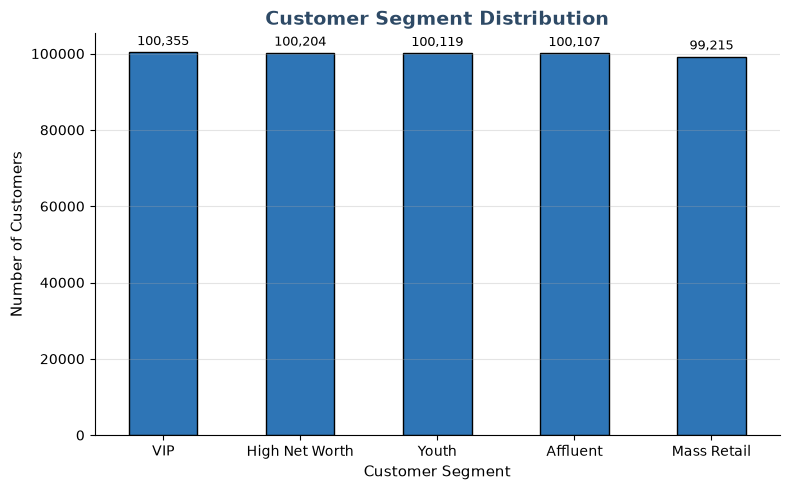

In [189]:
# Create the visualization for: Customer Segment Distribution.
plot_chart(
    customers["Customer_Segment"].value_counts(),
    "Customer Segment Distribution", "Customer Segment", "Number of Customers",
    kind="bar", figsize=(8, 5), rotation=0
)


## Business Question — Customer Concentration by State

**Question:** Which states have the largest customer populations?

**Why it matters:** Geographic concentration can guide regional marketing, branch planning, and resource allocation.

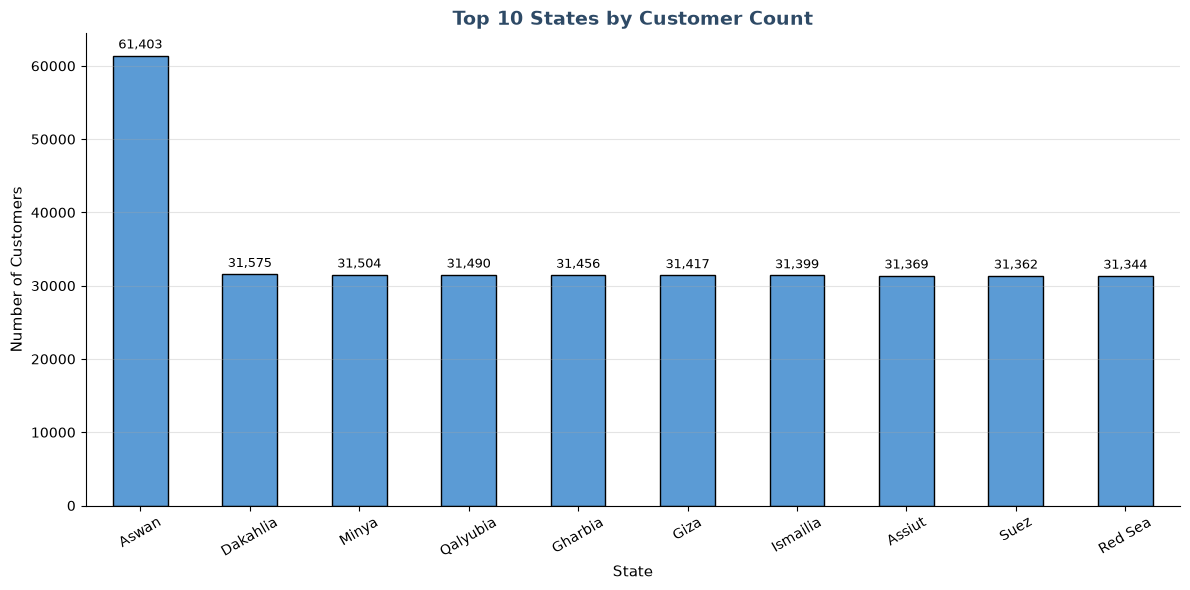

In [190]:
# Create the visualization for: Top 10 States by Customer Count.
plot_chart(
    customers["State"].value_counts().head(10),
    "Top 10 States by Customer Count", "State", "Number of Customers",
    kind="bar", figsize=(12, 6), rotation=30
)


## Business Question — Customer Age Distribution

**Question:** Which age group contains the largest number of customers?

**Why it matters:** Age distribution helps identify the core demographic and supports targeted product and communication strategies.

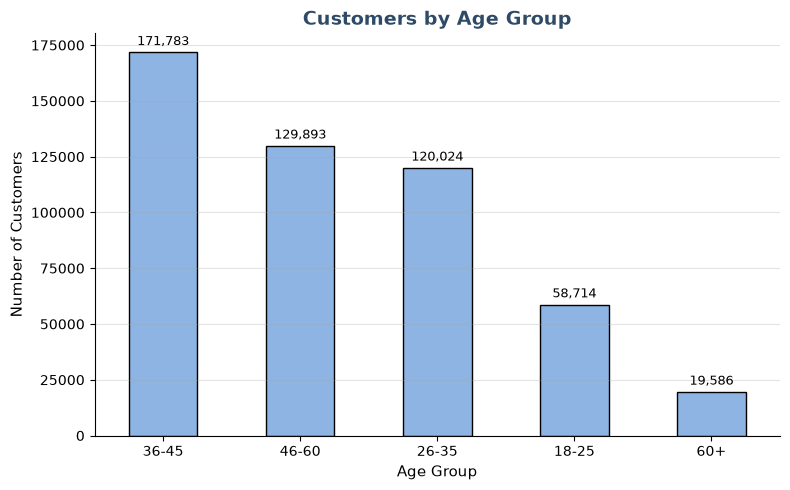

In [191]:
# Create the visualization for: Customers by Age Group.
plot_chart(
    customers["Age_Group"].value_counts(),
    "Customers by Age Group", "Age Group", "Number of Customers",
    kind="bar", figsize=(8, 5), rotation=0
)


## Business Question — Account Balance Distribution

**Question:** How are account balances distributed across customers?

**Why it matters:** Balance distribution shows whether deposits are broadly distributed or concentrated among high-balance accounts.

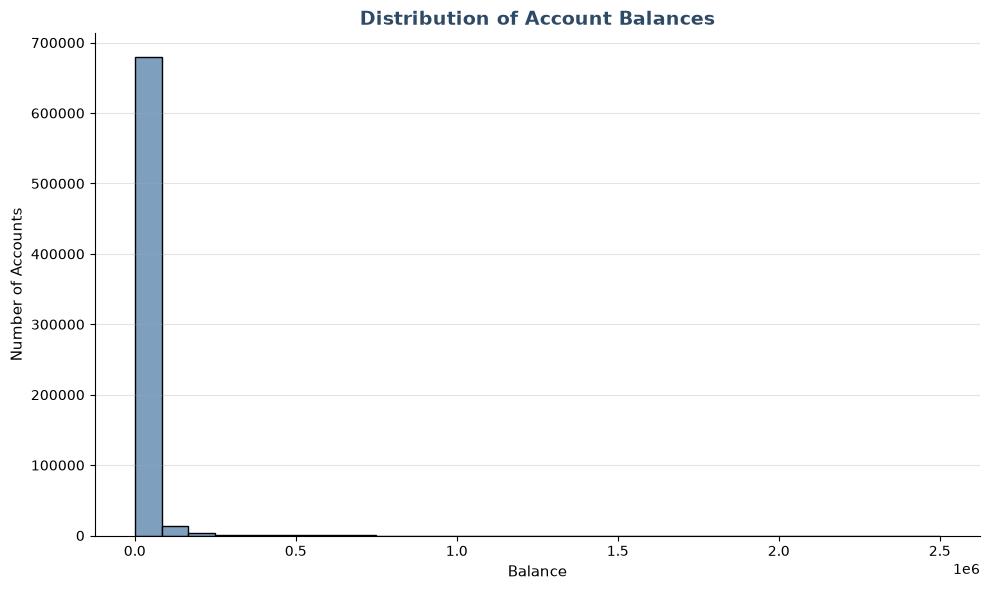

In [192]:
# Create the visualization for: Distribution of Account Balances.
plot_chart(
    accounts["Balance"],
    "Distribution of Account Balances", "Balance", "Number of Accounts",
    kind="hist", bins=30, figsize=(10, 6)
)


## Business Question — Most Common Account Type

**Question:** Which account type is most commonly held?

**Why it matters:** The most common account type represents a major part of product usage and can guide product management.

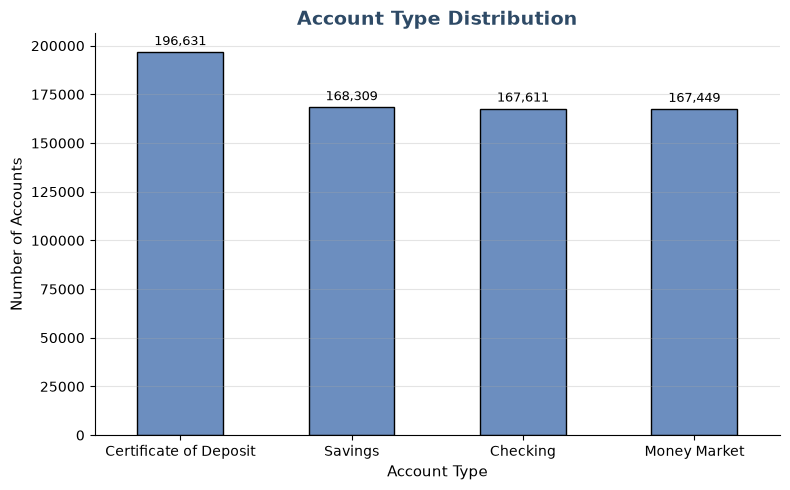

In [193]:
# Create the visualization for: Account Type Distribution.
plot_chart(
    accounts["Account_Type"].value_counts(),
    "Account Type Distribution", "Account Type", "Number of Accounts",
    kind="bar", figsize=(8, 5), rotation=0
)


## Business Question — Average Balance by Account Type

**Question:** Which account type has the highest average balance?

**Why it matters:** Comparing average balances helps identify products associated with higher customer balances.

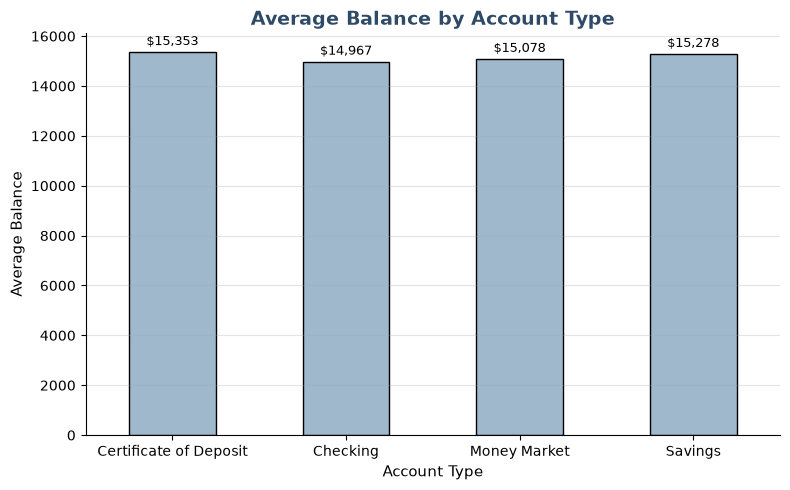

In [194]:
# Create the visualization for: Average Balance by Account Type.
plot_chart(
    accounts.groupby("Account_Type")["Balance"].mean(),
    "Average Balance by Account Type", "Account Type", "Average Balance",
    kind="bar", fmt="${:,.0f}", figsize=(8, 5), rotation=0
)


## Business Question — Accounts per Customer

**Question:** How many accounts does a customer typically hold?

**Why it matters:** Multi-account ownership is an indicator of product adoption and can reveal cross-selling opportunities.

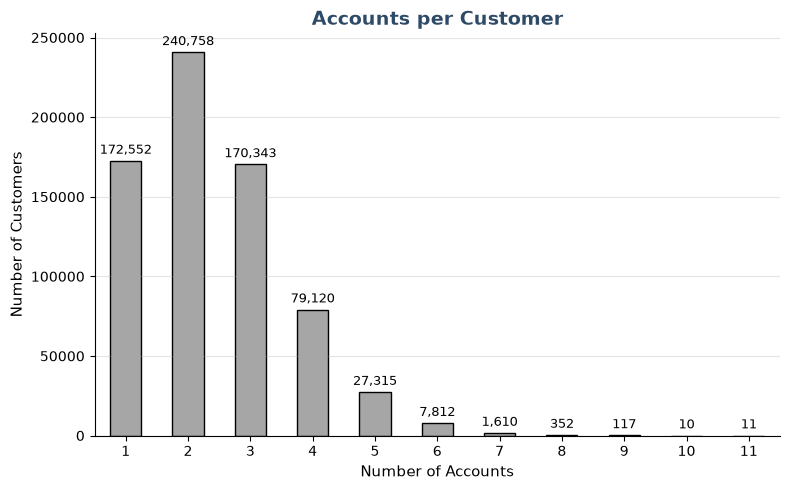

In [195]:
# Create the visualization for: Accounts per Customer.
plot_chart(
    accounts["Accounts_Per_Customer"].value_counts().sort_index(),
    "Accounts per Customer", "Number of Accounts", "Number of Customers",
    kind="bar", figsize=(8, 5), rotation=0
)


## Business Question — Transaction Amount Distribution

**Question:** What is the typical transaction amount, and how are large transactions distributed?

**Why it matters:** Transaction-size patterns help distinguish normal activity from transactions requiring additional monitoring.

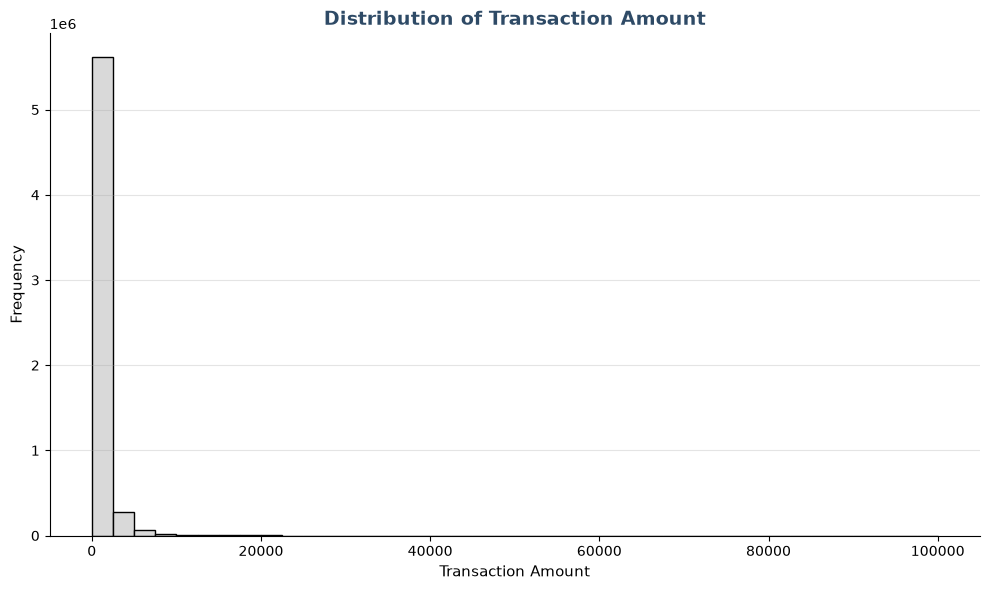

In [196]:
# Create the visualization for: Distribution of Transaction Amount.
plot_chart(
    transactions["Amount"],
    "Distribution of Transaction Amount", "Transaction Amount", "Frequency",
    kind="hist", bins=40, figsize=(10, 6)
)


## Business Question — Transaction Type Frequency

**Question:** Which transaction type occurs most frequently?

**Why it matters:** Transaction frequency shows how customers primarily use their accounts and can guide operational priorities.

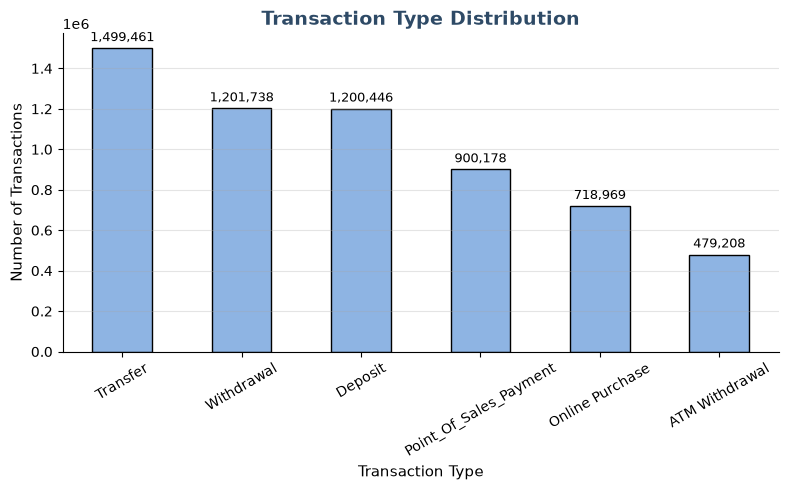

In [208]:
# Create the visualization for: Transaction Type Distribution.
plot_chart(
    transactions["Transaction_Type"].value_counts(),
    "Transaction Type Distribution", "Transaction Type", "Number of Transactions",
    kind="bar", figsize=(8, 5), rotation=30
)


## Business Question — Average Transaction Amount by Type

**Question:** Which transaction type has the highest average monetary value?

**Why it matters:** Average value highlights transaction types with greater financial impact, even when their volume is lower.

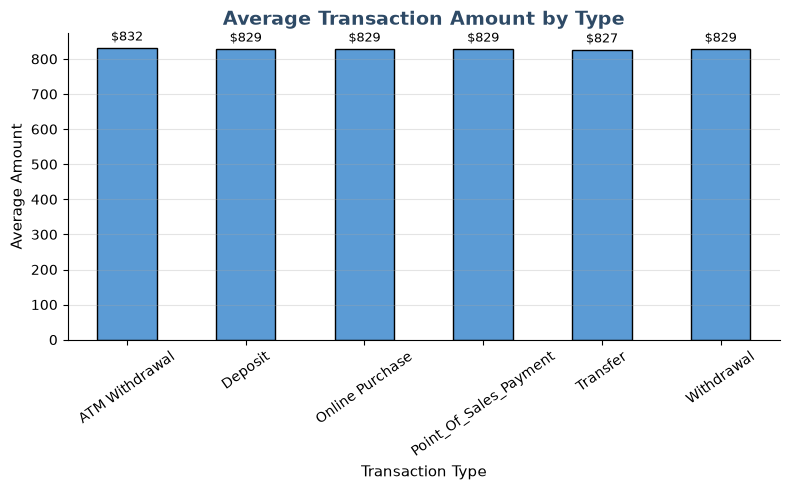

In [207]:
# Create the visualization for: Average Transaction Amount by Type.
plot_chart(
    transactions.groupby("Transaction_Type")["Amount"].mean(),
    "Average Transaction Amount by Type", "Transaction Type", "Average Amount",
    kind="bar", fmt="${:,.0f}", figsize=(8, 5), rotation=35
)


## Business Question — Branch Transaction Performance

**Question:** Which branches generate the highest total transaction amount?

**Why it matters:** Branch transaction performance can support staffing, capacity planning, and resource allocation.

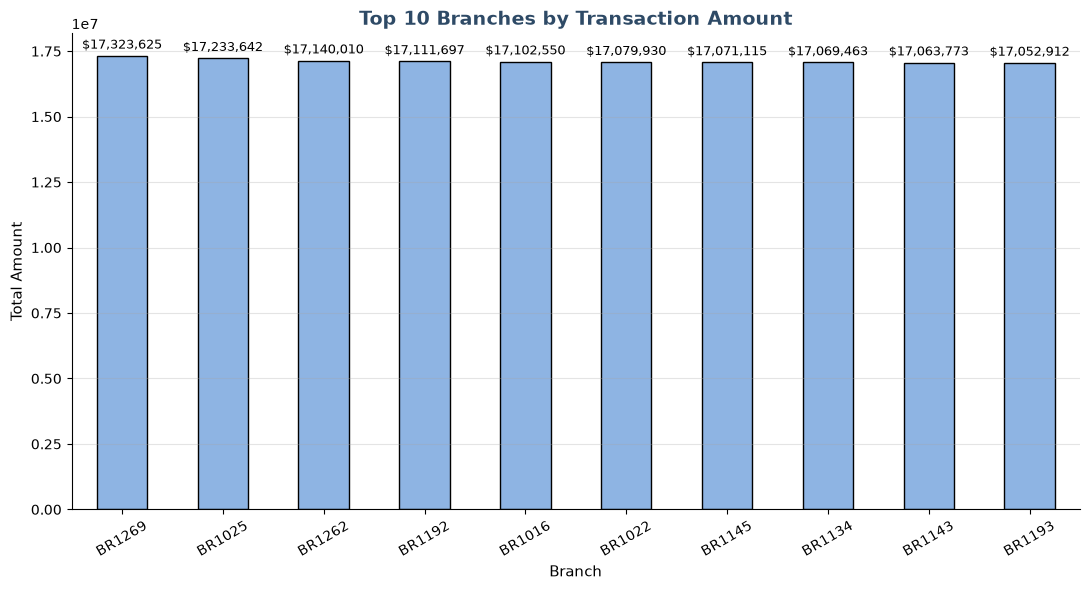

In [199]:
# Create the visualization for: Top 10 Branches by Transaction Amount.
plot_chart(
    transactions.groupby("Branch_ID")["Amount"].sum().sort_values(ascending=False).head(10),
    "Top 10 Branches by Transaction Amount", "Branch", "Total Amount",
    kind="bar", fmt="${:,.0f}", figsize=(11, 6), rotation=30
)


## Business Question — Transactions by Hour

**Question:** At what times of day do customers perform the most transactions?

**Why it matters:** Peak hours help the bank plan staffing, system capacity, and service availability.

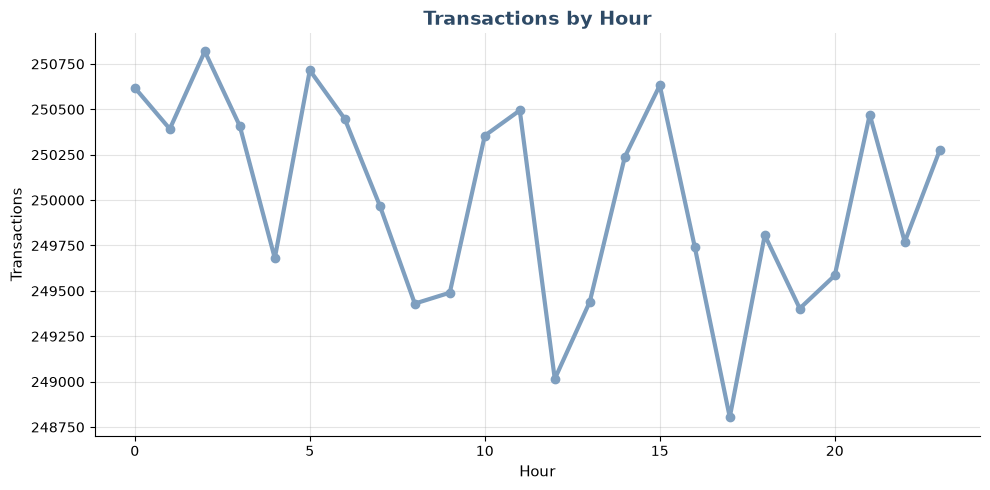

In [200]:
# Create the visualization for: Transactions by Hour.
plot_chart(
    transactions["Hour"].value_counts().sort_index(),
    "Transactions by Hour", "Hour", "Transactions",
    kind="line", marker="o", linewidth=3, figsize=(10, 5),
    grid_axis="both", rotation=0
)


## Business Question — Loan Status Distribution

**Question:** What proportion of loans are active, closed, or defaulted?

**Why it matters:** Loan status provides a high-level view of portfolio composition and potential credit-risk attention.

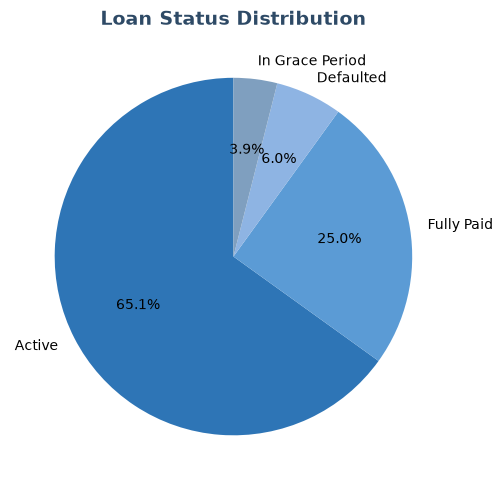

In [201]:
# Create the visualization for: Loan Status Distribution.
plot_pie(
    loans["Loan_Status"].value_counts(),
    "Loan Status Distribution", figsize=(7, 5)
)


## Business Question — Average Loan Amount by Type

**Question:** Which loan type has the highest average loan amount?

**Why it matters:** Average loan size helps identify products associated with greater capital exposure.

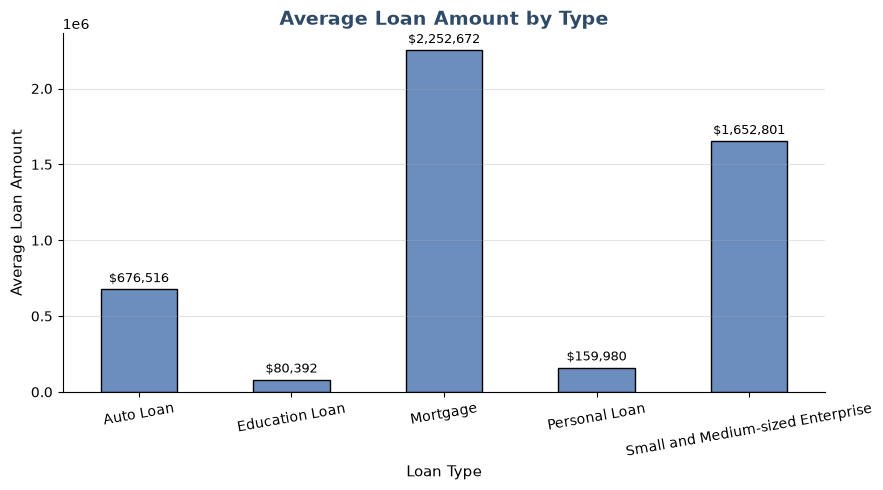

In [202]:
# Create the visualization for: Average Loan Amount by Type.
plot_chart(
    loans.groupby("Loan_Type")["Loan_Amount"].mean(),
    "Average Loan Amount by Type", "Loan Type", "Average Loan Amount",
    kind="bar", fmt="${:,.0f}", figsize=(9, 5), rotation=10
)


## Business Question — Card Type Distribution

**Question:** Which card type is the most popular among cardholders?

**Why it matters:** Card-product popularity helps guide product development, renewal, and customer-engagement strategies.

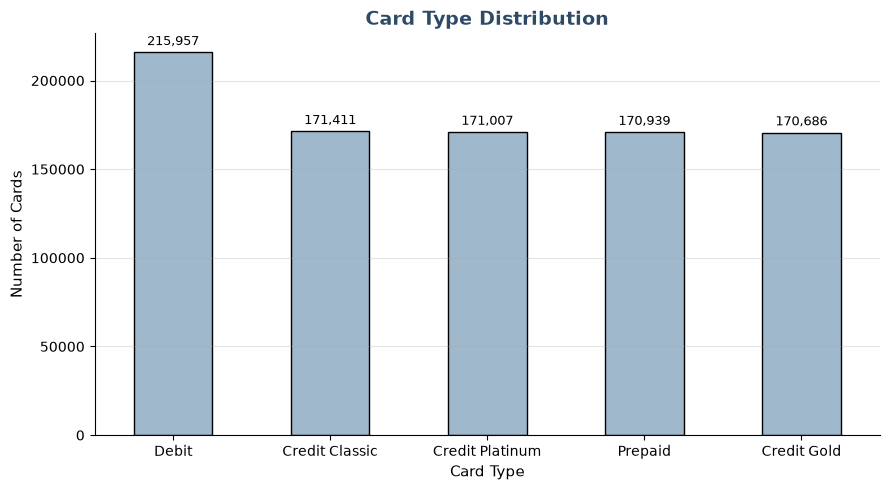

In [203]:
# Create the visualization for: Card Type Distribution.
plot_chart(
    cards["Card_Type"].value_counts(),
    "Card Type Distribution", "Card Type", "Number of Cards",
    kind="bar", figsize=(9, 5), rotation=0
)


## Business Question — Customer Support Satisfaction

**Question:** How satisfied are customers with support interactions?

**Why it matters:** Satisfaction is a direct indicator of support quality and can highlight service-improvement opportunities.

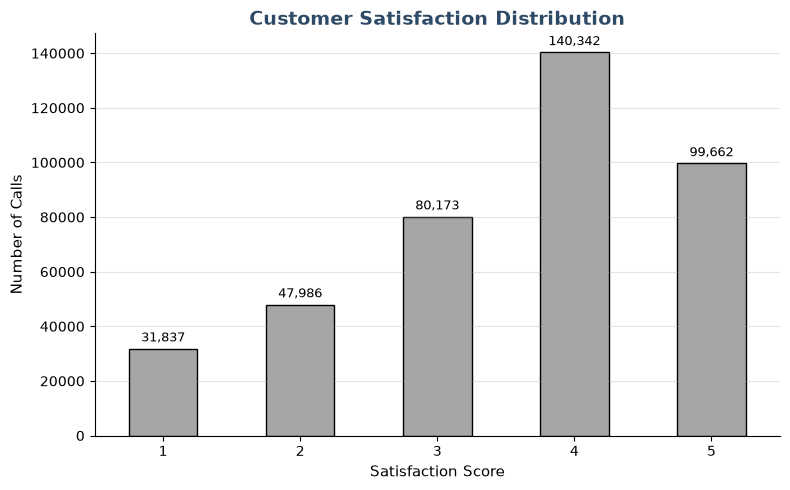

In [204]:
# Create the visualization for: Customer Satisfaction Distribution.
plot_chart(
    support_calls["Satisfaction_Score"].value_counts().sort_index(),
    "Customer Satisfaction Distribution", "Satisfaction Score", "Number of Calls",
    kind="bar", figsize=(8, 5), rotation=0
)


## Business Question — Average Resolution Time by Call Type

**Question:** Which support-call type takes the longest to resolve?

**Why it matters:** Long resolution times can indicate process complexity, workload issues, or a need for specialized workflows.

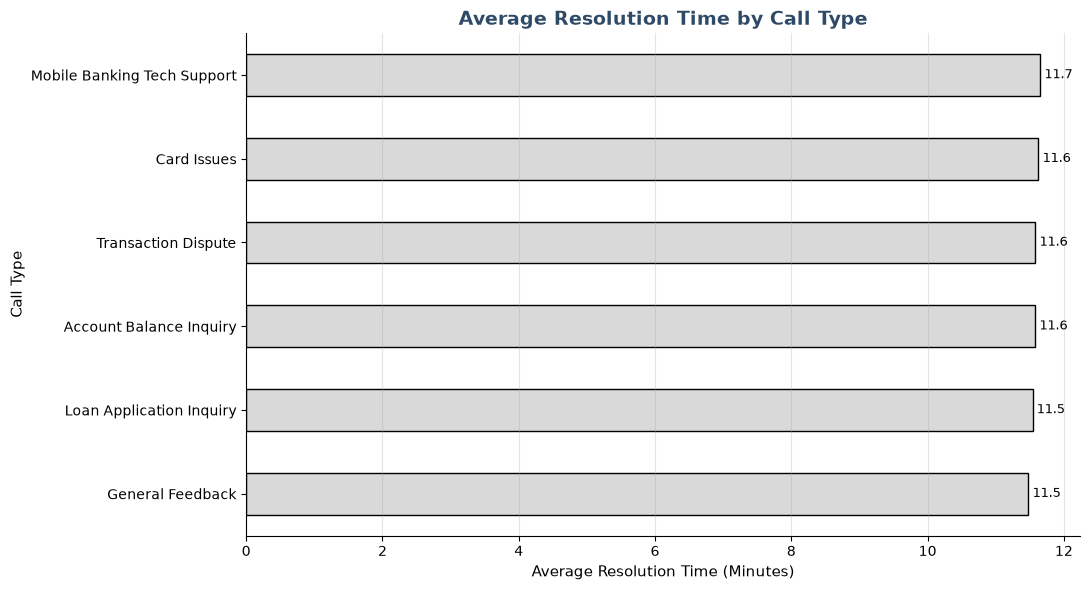

In [205]:
# Create the visualization for: Average Resolution Time by Call Type.
plot_chart(
    support_calls.groupby("Call_Type")["Resolution_Time_Mins"].mean().sort_values(),
    "Average Resolution Time by Call Type", "Average Resolution Time (Minutes)", "Call Type",
    kind="barh", fmt="{:.1f}", figsize=(11, 6), grid_axis="x"
)


## Business Question — RFM Customer Engagement

**Question:** Which combined RFM scores are most common, and what do they indicate about customer engagement?

**Why it matters:** RFM helps identify customers by recency, frequency, and monetary behavior for targeted retention and marketing.

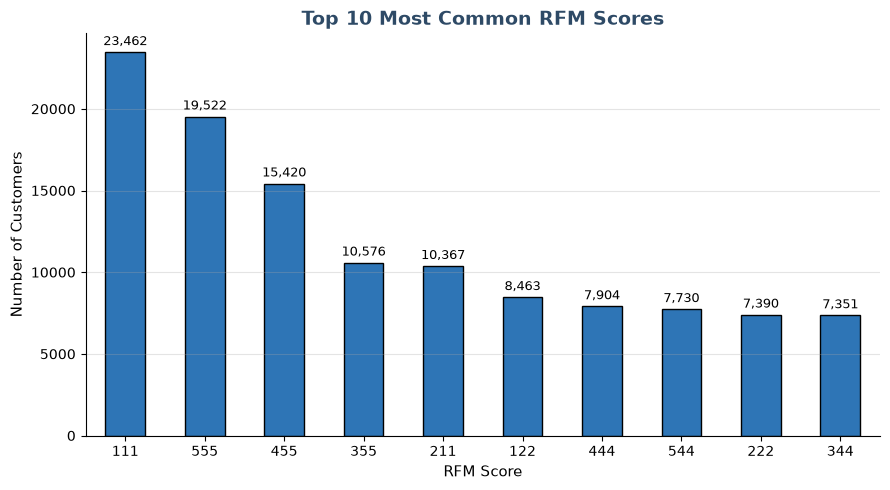

In [206]:
# Create the visualization for: Top 10 Most Common RFM Scores.
plot_chart(
    rfm["RFM_Score"].value_counts().head(10),
    "Top 10 Most Common RFM Scores", "RFM Score", "Number of Customers",
    kind="bar", figsize=(9, 5), rotation=0
)


## Final Analytical Summary

The project follows a complete data-analysis workflow:

1. **Clean and validate** the source data.
2. **Explore** the cleaned datasets and confirm their quality.
3. **Engineer features** that make banking behavior easier to analyze.
4. **Apply RFM analysis** to evaluate customer engagement and value.
5. **Export analytical tables** for Power BI.
6. **Translate findings into business questions and visualizations** for the final dashboard.

### Presentation Message
Raw banking data was transformed into reliable analytical datasets and then converted into customer, financial, operational, and retention insights that can support business decision-making.